**Data extraction**

Author: Jesús Enrique Miranda Blanco

# Setup

In [1]:
import pandas as pd
import numpy as np
from datetime import date, timedelta

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# import pandas_datareader.data as web
import yfinance as yf


pd.set_option("display.max_columns",80)

In [2]:
yf.__version__

'0.2.9'

# Stock Data

In [3]:
yesterday = str(date.today() - timedelta(days = 1))
print("Today's date:", yesterday)

Today's date: 2023-02-06


In [4]:
start_date = "2019-01-01"
tickers = ['MAT','DIS','KO', 'NVDA','PFE','MRNA', "AAPL", "META", "TSLA", "^GSPC"]
all_data = yf.download(tickers, start_date, yesterday)

[*********************100%***********************]  10 of 10 completed


In [7]:
all_data["Adj Close"]["AAPL"]

Date
2019-01-02 00:00:00-05:00     38.105137
2019-01-03 00:00:00-05:00     34.309589
2019-01-04 00:00:00-05:00     35.774239
2019-01-07 00:00:00-05:00     35.694607
2019-01-08 00:00:00-05:00     36.375057
                                ...    
2023-01-30 00:00:00-05:00    143.000000
2023-01-31 00:00:00-05:00    144.289993
2023-02-01 00:00:00-05:00    145.429993
2023-02-02 00:00:00-05:00    150.820007
2023-02-03 00:00:00-05:00    154.500000
Name: AAPL, Length: 1031, dtype: float64

In [9]:
np.max(all_data["Adj Close"]["AAPL"])

180.95973205566406

In [6]:
type(all_data)

pandas.core.frame.DataFrame

In [5]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1031 entries, 2019-01-02 00:00:00-05:00 to 2023-02-03 00:00:00-05:00
Data columns (total 60 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Adj Close, AAPL)   1031 non-null   float64
 1   (Adj Close, DIS)    1031 non-null   float64
 2   (Adj Close, KO)     1031 non-null   float64
 3   (Adj Close, MAT)    1031 non-null   float64
 4   (Adj Close, META)   1031 non-null   float64
 5   (Adj Close, MRNA)   1031 non-null   float64
 6   (Adj Close, NVDA)   1031 non-null   float64
 7   (Adj Close, PFE)    1031 non-null   float64
 8   (Adj Close, TSLA)   1031 non-null   float64
 9   (Adj Close, ^GSPC)  1031 non-null   float64
 10  (Close, AAPL)       1031 non-null   float64
 11  (Close, DIS)        1031 non-null   float64
 12  (Close, KO)         1031 non-null   float64
 13  (Close, MAT)        1031 non-null   float64
 14  (Close, META)       1031 non-null   float64
 15  (Close,

In [6]:
all_data.head(2)

Adj Close                                           \
                                AAPL         DIS         KO   MAT        META   
Date                                                                            
2019-01-02 00:00:00-05:00  38.105137  107.654343  41.413998  9.76  135.679993   
2019-01-03 00:00:00-05:00  34.309589  105.046211  41.158081  9.27  131.740005   

                                                                   \
                            MRNA       NVDA        PFE       TSLA   
Date                                                                
2019-01-02 00:00:00-05:00  15.33  33.805470  35.108093  20.674667   
2019-01-03 00:00:00-05:00  15.50  31.763042  34.125870  20.024000   

                                            Close                         \
                                 ^GSPC       AAPL         DIS         KO   
Date                                                                       
2019-01-02 00:00:00-05:00  2510.030029  39.480000  108.970001  46.930000   
2019-01-03 00:00:00-05:00  2447.889893  35.547501  106.330002  46.639999   

                                                                          \
                            MAT        META   MRNA       NVDA        PFE   
Date                                                                       
2019-01-02 00:00:00-05:00  9.76  135.679993  15.33  34.055000  41.034157   
2019-01-03 00:00:00-05:00  9.27  131.740005  15.50  31.997499  39.886147   

                                                        High              \
                                TSLA        ^GSPC       AAPL         DIS   
Date                                                                       
2019-01-02 00:00:00-05:00  20.674667  2510.030029  39.712502  109.139999   
2019-01-03 00:00:00-05:00  20.024000  2447.889893  36.430000  108.650002   

                                                                          \
                                  KO   MAT        META   MRNA       NVDA   
Date                                                                       
2019-01-02 00:00:00-05:00  47.220001  9.99  137.509995  15.45  34.619999   
2019-01-03 00:00:00-05:00  47.369999  9.80  137.169998  16.08  33.790001   

                                                                    Low  \
                                 PFE       TSLA        ^GSPC       AAPL   
Date                                                                      
2019-01-02 00:00:00-05:00  41.271347  21.008667  2519.489990  38.557499   
2019-01-03 00:00:00-05:00  41.119545  20.626667  2493.139893  35.500000   

                                                                           \
                                  DIS         KO   MAT        META   MRNA   
Date                                                                        
2019-01-02 00:00:00-05:00  107.730003  46.560001  9.66  128.559998  14.51   
2019-01-03 00:00:00-05:00  105.940002  46.529999  9.26  131.119995  15.20   

                                                                         \
                                NVDA        PFE       TSLA        ^GSPC   
Date                                                                      
2019-01-02 00:00:00-05:00  32.512501  40.455406  19.920000  2467.469971   
2019-01-03 00:00:00-05:00  31.922501  39.800758  19.825333  2443.959961   

                                Open                                           \
                                AAPL         DIS         KO   MAT        META   
Date                                                                            
2019-01-02 00:00:00-05:00  38.722500  108.099998  46.939999  9.83  128.990005   
2019-01-03 00:00:00-05:00  35.994999  108.480003  46.820000  9.73  134.690002   

                                                                   \
                            MRNA       NVDA        PFE       TSLA   
Date                                                                


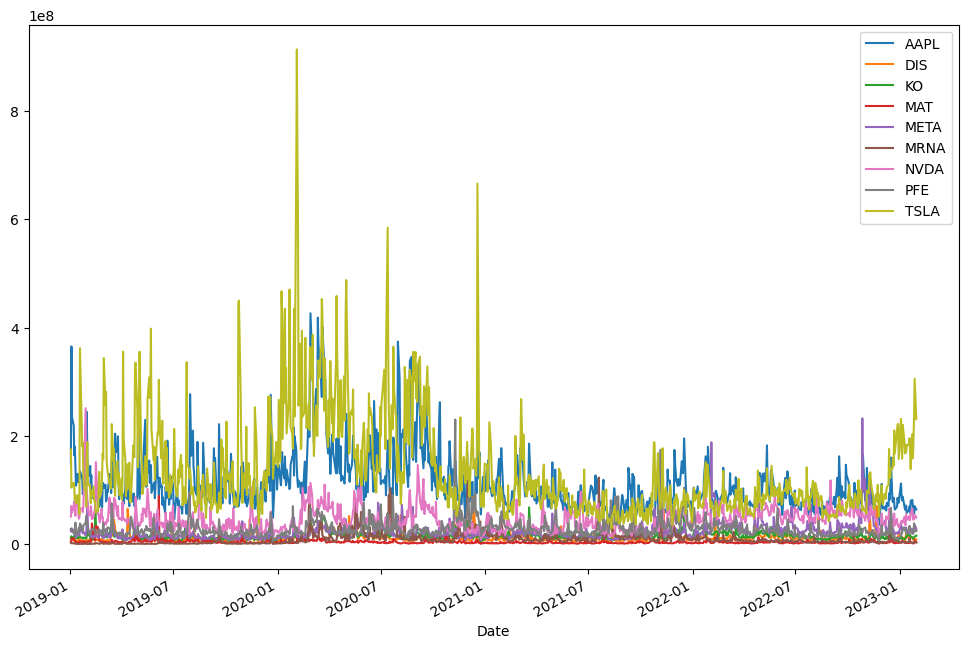

In [7]:
(
    all_data.Volume
).drop(columns='^GSPC').plot(
    figsize=(12,8)
);

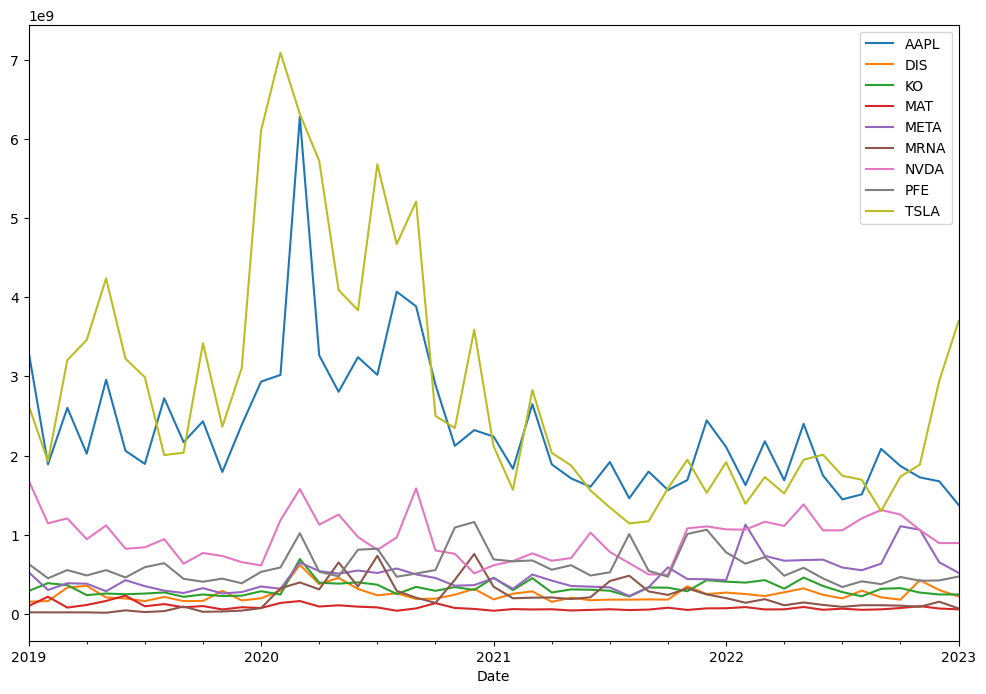

In [8]:
all_data.Volume.drop(columns='^GSPC').groupby(
    pd.PeriodIndex(
        all_data.index, 
        freq="M"
    )
).sum().plot(
    figsize=(12,8)
);

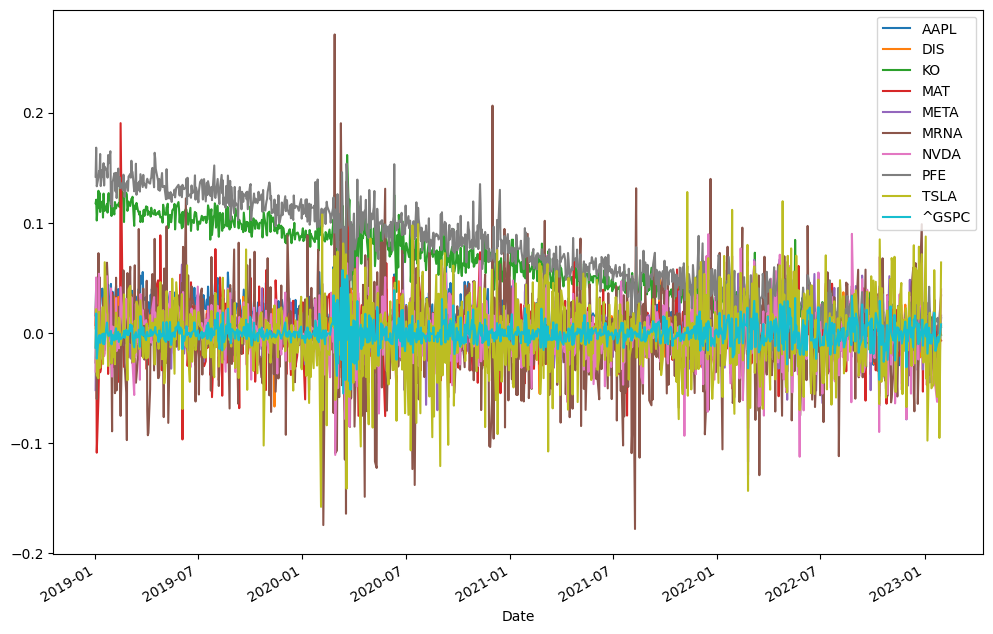

In [9]:
(
    (all_data.Open - all_data["Adj Close"]) / all_data.Open
).plot(
    figsize=(12,8)
);

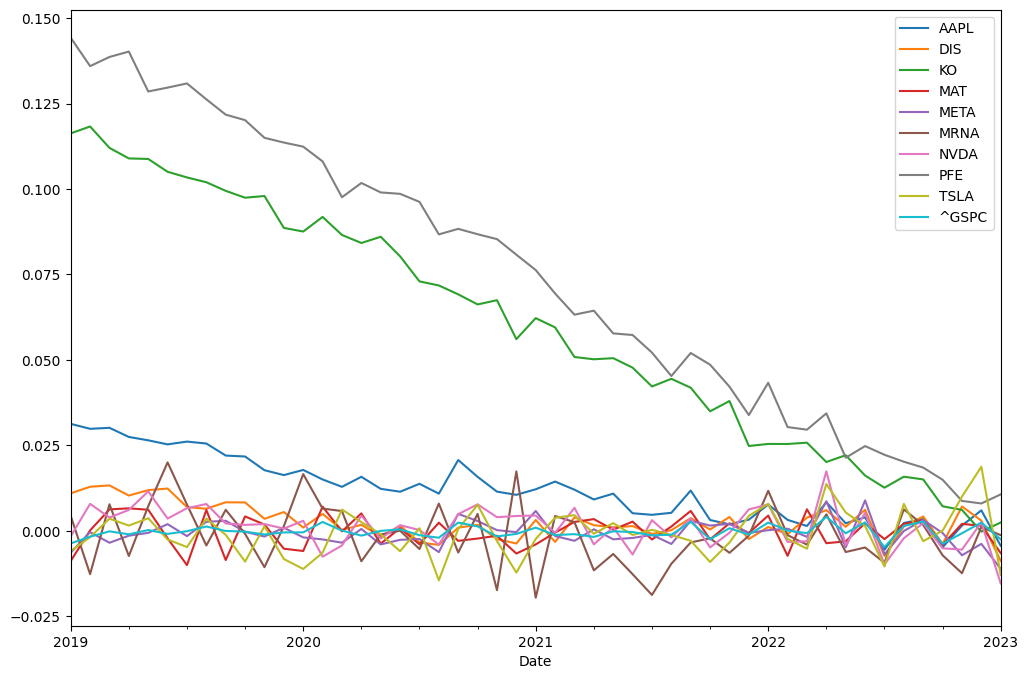

In [10]:
(
    (all_data.Open - all_data["Adj Close"]) / all_data.Open
).groupby(
    pd.PeriodIndex(
        all_data.index, 
        freq="M"
    )
).mean().plot(
    figsize=(12,8)
);

In [11]:
price_data = all_data["Adj Close"]
price_data.head()

,AAPL,DIS,KO,MAT,META,MRNA,NVDA,PFE,TSLA,^GSPC
Date,,,,,,,,,,
2019-01-02 00:00:00-05:00,38.105137,107.654343,41.413998,9.76,135.679993,15.330000,33.805470,35.108093,20.674667,2510.030029
2019-01-03 00:00:00-05:00,34.309589,105.046211,41.158081,9.27,131.740005,15.500000,31.763042,34.125870,20.024000,2447.889893
2019-01-04 00:00:00-05:00,35.774227,108.286606,41.978764,10.41,137.949997,16.959999,33.798027,34.905155,21.179333,2531.939941
2019-01-07 00:00:00-05:00,35.694611,109.225136,41.431633,11.21,138.050003,16.270000,35.587318,35.091850,22.330667,2549.689941
2019-01-08 00:00:00-05:00,36.375065,110.074753,41.899345,11.74,142.529999,16.950001,34.701355,35.254204,22.356667,2574.409912


In [12]:
price_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1027 entries, 2019-01-02 00:00:00-05:00 to 2023-01-30 00:00:00-05:00
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1027 non-null   float64
 1   DIS     1027 non-null   float64
 2   KO      1027 non-null   float64
 3   MAT     1027 non-null   float64
 4   META    1027 non-null   float64
 5   MRNA    1027 non-null   float64
 6   NVDA    1027 non-null   float64
 7   PFE     1027 non-null   float64
 8   TSLA    1027 non-null   float64
 9   ^GSPC   1027 non-null   float64
dtypes: float64(10)
memory usage: 88.3 KB


## S&P 500 

In [13]:
tickers_sp500 = pd.read_html(
    'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]
tickers_sp500.head()

,Symbol,Security,SEC filings,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,reports,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1976-08-09,66740,1902
1,AOS,A. O. Smith,reports,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott,reports,Health Care,Health Care Equipment,"North Chicago, Illinois",1964-03-31,1800,1888
3,ABBV,AbbVie,reports,Health Care,Pharmaceuticals,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,reports,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


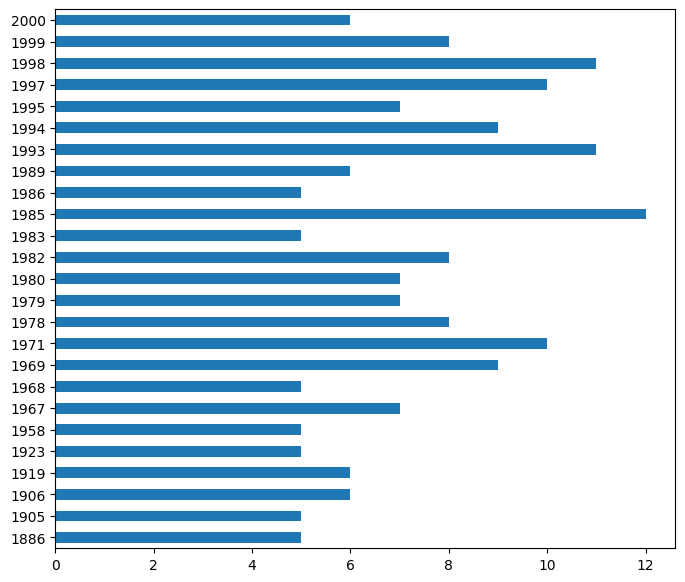

In [14]:
tickers_sp500.Founded.value_counts().sort_values().tail(25).sort_index().plot(
    kind='barh',
    figsize=(8,7)
);

In [15]:
tickers_sp500[
    tickers_sp500.Founded == "1886"
]

,Symbol,Security,SEC filings,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
34,AWK,American Water Works,reports,Utilities,Water Utilities,"Camden, New Jersey",2016-03-04,1410636,1886
116,CMS,CMS Energy,reports,Utilities,Multi-Utilities,"Jackson, Michigan",1999-05-03,811156,1886
117,KO,The Coca-Cola Company,reports,Consumer Staples,Soft Drinks,"Atlanta, Georgia",1957-03-04,21344,1886
166,EIX,Edison International,reports,Utilities,Electric Utilities,"Rosemead, California",1957-03-04,827052,1886
266,JNJ,Johnson & Johnson,reports,Health Care,Pharmaceuticals,"New Brunswick, New Jersey",1973-06-30,200406,1886


In [16]:
tickers_sp500[
    tickers_sp500.Founded.min() == tickers_sp500.Founded
]

,Symbol,Security,SEC filings,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
70,BK,BNY Mellon,reports,Financials,Asset Management & Custody Banks,"New York City, New York",1995-03-31,1390777,1784


In [53]:
sp_price_data = yf.download(tickers_sp500.Symbol.to_list(),'2022-12-01','2022-12-31', auto_adjust=True)['Close']
sp_price_data.head()

[*********************100%***********************]  503 of 503 completed

2 Failed downloads:
- BF.B: No data found for this date range, symbol may be delisted
- BRK.B: No timezone found, symbol may be delisted


,A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,AKAM,ALB,ALGN,ALK,ALL,ALLE,AMAT,AMCR,AMD,AME,AMGN,AMP,AMT,AMZN,ANET,ANSS,AON,AOS,APA,...,URI,USB,V,VFC,VICI,VLO,VMC,VRSK,VRSN,VRTX,VTR,VTRS,VZ,WAB,WAT,WBA,WBD,WDC,WEC,WELL,WFC,WHR,WM,WMB,WMT,WRB,WRK,WST,WTW,WY,WYNN,XEL,XOM,XRAY,XYL,YUM,ZBH,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-12-01 00:00:00-05:00,155.887512,13.98,149.718033,148.309998,160.108002,171.630005,107.443527,59.759998,301.596344,344.109985,170.719986,91.320000,266.657928,206.929993,88.100189,96.480003,28.539753,71.910004,62.782314,128.009995,199.720001,95.199997,274.851288,201.770004,47.410000,132.009995,114.059998,107.010002,12.38,77.480003,143.068115,285.940002,330.929993,219.675018,95.500000,139.779999,259.609985,302.535522,60.179401,46.461365,...,356.420013,44.847855,217.000000,32.884434,33.461285,132.029999,183.830002,185.827576,204.570007,320.760010,45.911999,11.24,37.736744,103.040001,346.929993,41.310001,11.63,35.840000,97.290001,70.989998,46.869999,149.020004,167.820007,34.480785,152.793991,74.690079,38.020000,241.845901,245.773468,32.279999,84.040001,69.711411,110.800003,31.313145,113.800003,129.190002,123.116516,268.820007,51.990002,156.272812
2022-12-02 00:00:00-05:00,155.438187,13.97,151.429947,147.809998,162.118881,173.990005,107.602798,60.599998,298.907349,341.529999,168.630005,91.709999,268.598511,201.110001,87.444656,95.120003,28.490067,72.339996,62.434078,128.479996,201.259995,93.790001,283.826965,198.410004,46.700001,130.850006,114.519997,106.709999,12.50,74.980003,144.166428,285.510010,330.179993,217.759186,94.129997,135.039993,256.739990,306.238953,60.079903,46.849205,...,356.570007,45.134644,217.660004,32.629063,33.629284,127.070000,184.490005,185.128754,202.100006,321.369995,45.783287,11.17,37.589066,103.379997,347.369995,41.480000,11.55,35.450001,96.059998,71.080002,45.939999,146.119995,169.809998,34.520283,152.644562,75.047119,37.849998,244.174225,246.720245,32.419998,85.150002,68.668571,109.860001,31.552176,113.529999,129.679993,122.737236,274.859985,52.250000,157.050980
2022-12-05 00:00:00-05:00,152.472595,14.11,146.808777,146.630005,162.396255,171.279999,104.934891,59.169998,291.547455,334.089996,167.839996,90.769997,263.115082,198.389999,86.659996,94.519997,28.191950,71.040001,61.220219,129.550003,196.830002,91.599998,264.807343,187.910004,46.709999,128.440002,111.019997,106.430000,12.27,73.620003,141.860001,284.910004,321.170013,214.026810,91.010002,132.830002,249.289993,308.195496,59.522682,45.456955,...,345.670013,43.423801,213.679993,28.985058,32.907879,120.959999,179.000000,182.842590,197.289993,317.600006,45.010986,10.92,36.496246,101.739998,340.290009,41.209999,11.15,34.790001,94.250000,70.190002,43.660000,141.460007,167.789993,33.740219,151.080460,73.718155,36.650002,239.267761,245.823303,31.520000,85.769997,68.211708,106.849998,30.496452,112.040001,130.910004,122.048538,261.799988,48.419998,154.965881
2022-12-06 00:00:00-05:00,151.124619,14.33,144.008362,142.910004,162.178314,169.320007,103.391869,60.540001,284.247314,331.149994,166.509995,90.849998,257.283325,194.610001,87.290001,96.370003,27.953455,71.089996,61.379414,129.309998,195.979996,89.809998,257.578857,186.039993,46.299999,130.309998,109.169998,104.709999,12.15,70.269997,139.820007,283.290009,321.799988,210.959503,88.250000,129.039993,243.899994,307.416870,59.074917,43.627140,...,347.290009,42.464539,209.080002,28.867191,33.145054,118.860001,177.949997,181.734451,197.449997,311.809998,44.585232,10.93,36.319031,100.430000,337.589996,40.590000,10.61,33.889999,95.419998,68.199997,43.400002,141.860001,165.559998,33.049026,149.327072,74.789268,36.450001,234.820969,245.962830,31.020000,85.410004,68.847343,103.879997,29.988510,110.809998,130.619995,121.160225,254.210007,47.139999,152.691223
2022-12-07 00:00:00-05:00,153.501068,13.55,145.116638,140.940002,163.842499,170.289993,104.337585,60.150002,285.522095,326.679993,166.00

In [54]:
sp_price_data.mean().sort_values().dropna().tail(10)

TDG      618.597148
EQIX     674.838100
BLK      706.617336
REGN     739.196187
ORLY     832.144758
MTD     1453.231428
CMG     1482.443801
BKNG    2000.517619
AZO     2444.152344
NVR     4686.075684
dtype: float64

# fredapi

** Agregar ss para crear api key en freapi

In [ ]:
import pandas as pd 
import requests 
import json 
# import plotly.graph_objects as go
from fredapi import Fred

In [22]:
from api_keys import fred_api_key
fred = Fred(api_key=fred_api_key)
sp500_index_data = fred.get_series('SP500')

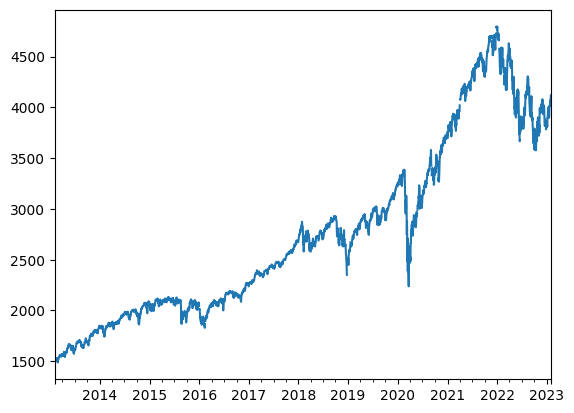

In [23]:
sp500_index_data.plot();

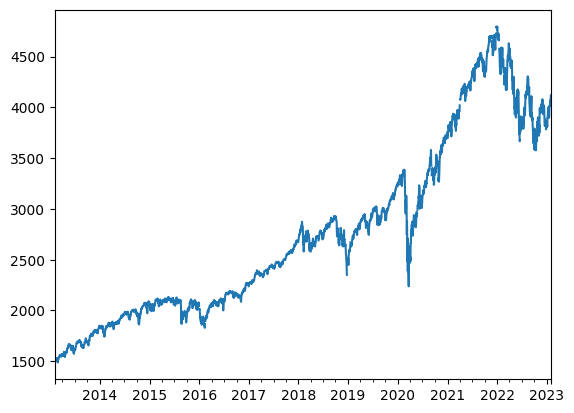

In [24]:
gdp_data = fred.get_series_first_release('GDP')
sp500_index_data.plot();

In [25]:
fred.search('fed rate').T

series id,FEDTARMD,DFF,FEDFUNDS,FF,FEDTARMDLR,FEDTARRM,FEDTARRL,FEDTARRH,FEDTARCTH,PCREDIT8,FEDTARCTM,FEDTARCTLLR,FEDTARRMLR,FEDTARCTL,FEDTARCTHLR,FEDTARCTMLR,FEDTARRHLR,FEDTARRLLR,DFEDTARU,T10Y2Y,CORESTICKM159SFRBATL,T10Y2YM,CORESTICKM158SFRBATL,CORESTICKM157SFRBATL,CORESTICKM679SFRBATL,M2V,RIFSPFFNB,RIFSPFFNA,T10YIE,M2SL,RIFSPFFNBWAW,T10Y3M,T10YIEM,DGS10,T5YIE,STLENI,T10Y3MM,GS10,WGS10YR,PCETRIM12M159SFRBDAL,...,BOGZ1LA144104005A,IPNCONGD,IPNMAN,IPG3364S,CAPUTLG2211S,IPG315A6S,EXITUS,EXFRUS,BOGZ1FA632051103Q,BOGZ1FA673065500Q,TODNS,EFFR1,MIPHCI,NYPHCI,INPHCI,TXPHCI,GAFISA156MSFRBPHI,GAFDSA156MSFRBPHI,GACDSA156MSFRBPHI,GACISA156MSFRBPHI,WBBNDIF066MSFRBPHI,UOFDFSA066MSFRBPHI,MSWP1,IMPORTSGOODSNOW,EQUIPNOW,GOVCONTRIBNOW,SFTPINDM114SFRBSF,TX10211000M175FRBDAL,BOGZ1FA673065500A,WSWP1,RIFLDIY01NA,SOFR25,IPG315A6SQ,IPG3364SQ,CAPUTLG2211SQ,CAPUTLG2211A,IPB51200SQ,IPGMFNSQ,BOGZ1LA384104005A,BOGZ1FA632051103A
id,FEDTARMD,DFF,FEDFUNDS,FF,FEDTARMDLR,FEDTARRM,FEDTARRL,FEDTARRH,FEDTARCTH,PCREDIT8,FEDTARCTM,FEDTARCTLLR,FEDTARRMLR,FEDTARCTL,FEDTARCTHLR,FEDTARCTMLR,FEDTARRHLR,FEDTARRLLR,DFEDTARU,T10Y2Y,CORESTICKM159SFRBATL,T10Y2YM,CORESTICKM158SFRBATL,CORESTICKM157SFRBATL,CORESTICKM679SFRBATL,M2V,RIFSPFFNB,RIFSPFFNA,T10YIE,M2SL,RIFSPFFNBWAW,T10Y3M,T10YIEM,DGS10,T5YIE,STLENI,T10Y3MM,GS10,WGS10YR,PCETRIM12M159SFRBDAL,...,BOGZ1LA144104005A,IPNCONGD,IPNMAN,IPG3364S,CAPUTLG2211S,IPG315A6S,EXITUS,EXFRUS,BOGZ1FA632051103Q,BOGZ1FA673065500Q,TODNS,EFFR1,MIPHCI,NYPHCI,INPHCI,TXPHCI,GAFISA156MSFRBPHI,GAFDSA156MSFRBPHI,GACDSA156MSFRBPHI,GACISA156MSFRBPHI,WBBNDIF066MSFRBPHI,UOFDFSA066MSFRBPHI,MSWP1,IMPORTSGOODSNOW,EQUIPNOW,GOVCONTRIBNOW,SFTPINDM114SFRBSF,TX10211000M175FRBDAL,BOGZ1FA673065500A,WSWP1,RIFLDIY01NA,SOFR25,IPG315A6SQ,IPG3364SQ,CAPUTLG2211SQ,CAPUTLG2211A,IPB51200SQ,IPGMFNSQ,BOGZ1LA384104005A,BOGZ1FA632051103A
realtime_start,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,...,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00
realtime_end,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-

In [26]:
personal_income_series = fred.search_by_release(175, limit=5, order_by='popularity', sort_order='desc')

In [27]:
personal_income_series['title']

series id
PCPI06037      Per Capita Personal Income in Los Angeles Coun...
PCPI06075      Per Capita Personal Income in San Francisco Co...
PCPI12099      Per Capita Personal Income in Palm Beach Count...
SEAT653PCPI    Per Capita Personal Income in Seattle-Tacoma-B...
PCPI12086      Per Capita Personal Income in Miami-Dade Count...
Name: title, dtype: object

<AxesSubplot: >

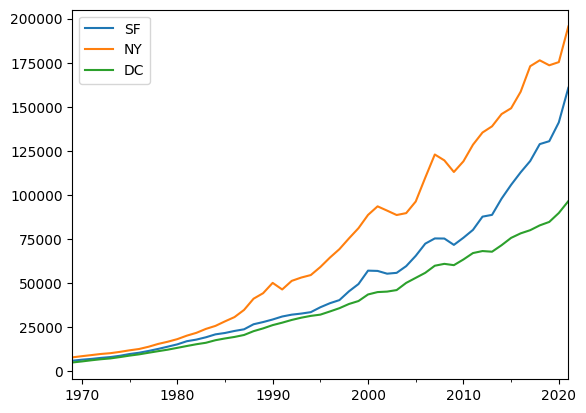

In [28]:
df = {}
df['SF'] = fred.get_series('PCPI06075')
df['NY'] = fred.get_series('PCPI36061')
df['DC'] = fred.get_series('PCPI11001')
df = pd.DataFrame(df)
df.plot()

In [29]:
df = fred.search_by_category(101, limit=10, order_by='popularity', sort_order='desc')
df['title']

series id
TOTALSL                  Total Consumer Credit Owned and Securitized
TERMCBCCALLNS      Commercial Bank Interest Rate on Credit Card P...
REVOLSL              Revolving Consumer Credit Owned and Securitized
TERMCBAUTO48NS     Finance Rate on Consumer Installment Loans at ...
SLOAS                            Student Loans Owned and Securitized
RIFLPBCIANM60NM    Finance Rate on Consumer Installment Loans at ...
MVLOAS                     Motor Vehicle Loans Owned and Securitized
TERMCBPER24NS      Finance Rate on Personal Loans at Commercial B...
TERMCBCCINTNS      Commercial Bank Interest Rate on Credit Card P...
TOTALSLAR                    Percent Change of Total Consumer Credit
Name: title, dtype: object

In [30]:
state_df = df[~df['title'].str.startswith('Per Capita Personal Income in the')]

In [31]:
len(state_df)

10

In [32]:
state_df.id.str[:2]

series id
TOTALSL            TO
TERMCBCCALLNS      TE
REVOLSL            RE
TERMCBAUTO48NS     TE
SLOAS              SL
RIFLPBCIANM60NM    RI
MVLOAS             MV
TERMCBPER24NS      TE
TERMCBCCINTNS      TE
TOTALSLAR          TO
Name: id, dtype: object

In [33]:
fred.search("potential inflation").T

series id,FEDTARMDLR,GDPC1CTMLR,UNRATEMDLR,GDPC1MDLR,GDPC1RHLR,PCECTPIMDLR,UNRATECTMLR,FEDTARCTLLR,FEDTARRMLR,PCECTPIRLLR,PCECTPICTMLR,PCECTPICTLLR,GDPC1RMLR,FEDTARCTHLR,FEDTARCTMLR,UNRATERMLR,FEDTARRHLR,FEDTARRLLR,UNRATECTLLR,GDPC1RLLR,GDPC1CTLLR,PCECTPIRMLR,PCECTPICTHLR,PCECTPIRHLR,GDPC1CTHLR,UNRATERHLR,UNRATECTHLR,UNRATERLLR,GDPPOT,NROU,NROUST,CPIEHOUSE,CPIEALL,CPIEMEDCARE,CPIEBEV,CPIETRANS,CPIEREC,CPIECOMEDU,CPIEAPPAREL,CPIEOTRGS
id,FEDTARMDLR,GDPC1CTMLR,UNRATEMDLR,GDPC1MDLR,GDPC1RHLR,PCECTPIMDLR,UNRATECTMLR,FEDTARCTLLR,FEDTARRMLR,PCECTPIRLLR,PCECTPICTMLR,PCECTPICTLLR,GDPC1RMLR,FEDTARCTHLR,FEDTARCTMLR,UNRATERMLR,FEDTARRHLR,FEDTARRLLR,UNRATECTLLR,GDPC1RLLR,GDPC1CTLLR,PCECTPIRMLR,PCECTPICTHLR,PCECTPIRHLR,GDPC1CTHLR,UNRATERHLR,UNRATECTHLR,UNRATERLLR,GDPPOT,NROU,NROUST,CPIEHOUSE,CPIEALL,CPIEMEDCARE,CPIEBEV,CPIETRANS,CPIEREC,CPIECOMEDU,CPIEAPPAREL,CPIEOTRGS
realtime_start,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00
realtime_end,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00
title,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Longer Run FOMC Summary of Economic Projection...,Real Potential Gross Domestic Product,Noncyclical Rate of Unemployment,Natural Rate of Unemployme

In [48]:
fred.search("Mexico").T

series id,NGDPRSAXDCMXQ,NGDPRXDCMXA,NGDPRNSAXDCMXQ,DEXMXUS,EXMXUS,AEXMXUS,STTMINWGNM,MEXCPIALLMINMEI,MEXCPIALLAINMEI,MEXCPIALLQINMEI,SIPOVGINIMEX,NMUR,NMURN,LAUST350000000000003A,MEXCPIENGQINMEI,MEXCPIENGMINMEI,MEXCPIENGAINMEI,ATNHPIUS10740Q,RGDPNAMXA666NRUG,INTGSTMXM193N,QMXR628BIS,QMXR368BIS,MKTGDPMXA646NWDB,IRLTLT01MXM156N,MEXNGDPRPCH,IRLTLT01MXQ156N,IRLTLT01MXA156N,NMNGSP,FPCPITOTLZGMEX,NMNQGSP,LBSSA35,NYGDPPCAPKDMEX,LBSNSA35,MEHOINUSNMA672N,NMPOP,GGGDTAMXA188N,NAEXKP01MXQ189S,NAEXKP01MXQ657S,MEXGGXWDGGDP,NAEXKP01MXQ661S,...,NMIDNA475SCEN,NMMNEA475SCEN,NMSMRA475SCEN,NMCOKA475SCEN,NMSHNA475SCEN,QTAXT50QTAXCAT3NMNO,NMCIVA475SCEN,NMWHEA,QTAXT27QTAXCAT3NMNO,NMACCOMDRGSP,QTAXT15QTAXCAT3NMNO,NMMDAA475SCEN,NMTRUCKTRANNGSP,QTAXT41QTAXCAT3NMNO,NMHUNTLICTAX,NMFLKA475SCEN,NMPIPETRANRGSP,NMFSMA475SCEN,NMWFOR,NMAMBHCNGSP,EMISSCO2CCLCCBNMA,NMAMBHCRGSP,NMCSXXA475SCEN,NMPCECLTH,NMPCEPCHOUSUTL,NMNATRESMINQGSP,NMFURNMANRGSP,NMMOTPICSNDRGSP,NMTRANSUTILQGSP,PPCIUBAANM35000A156NCEN,NMPETCOALMANQGSP,NMSECCOMINVQGSP,NMPCELRPTSLSGSNPIS,NMAGOA475SCEN,NMAIRTRANNGSP,CBUSAPPNSANM,NMATGA475SCEN,NMANHHA052SCEN,NMAGRRQGSP,NMARTETRTACCFDRGSP
id,NGDPRSAXDCMXQ,NGDPRXDCMXA,NGDPRNSAXDCMXQ,DEXMXUS,EXMXUS,AEXMXUS,STTMINWGNM,MEXCPIALLMINMEI,MEXCPIALLAINMEI,MEXCPIALLQINMEI,SIPOVGINIMEX,NMUR,NMURN,LAUST350000000000003A,MEXCPIENGQINMEI,MEXCPIENGMINMEI,MEXCPIENGAINMEI,ATNHPIUS10740Q,RGDPNAMXA666NRUG,INTGSTMXM193N,QMXR628BIS,QMXR368BIS,MKTGDPMXA646NWDB,IRLTLT01MXM156N,MEXNGDPRPCH,IRLTLT01MXQ156N,IRLTLT01MXA156N,NMNGSP,FPCPITOTLZGMEX,NMNQGSP,LBSSA35,NYGDPPCAPKDMEX,LBSNSA35,MEHOINUSNMA672N,NMPOP,GGGDTAMXA188N,NAEXKP01MXQ189S,NAEXKP01MXQ657S,MEXGGXWDGGDP,NAEXKP01MXQ661S,...,NMIDNA475SCEN,NMMNEA475SCEN,NMSMRA475SCEN,NMCOKA475SCEN,NMSHNA475SCEN,QTAXT50QTAXCAT3NMNO,NMCIVA475SCEN,NMWHEA,QTAXT27QTAXCAT3NMNO,NMACCOMDRGSP,QTAXT15QTAXCAT3NMNO,NMMDAA475SCEN,NMTRUCKTRANNGSP,QTAXT41QTAXCAT3NMNO,NMHUNTLICTAX,NMFLKA475SCEN,NMPIPETRANRGSP,NMFSMA475SCEN,NMWFOR,NMAMBHCNGSP,EMISSCO2CCLCCBNMA,NMAMBHCRGSP,NMCSXXA475SCEN,NMPCECLTH,NMPCEPCHOUSUTL,NMNATRESMINQGSP,NMFURNMANRGSP,NMMOTPICSNDRGSP,NMTRANSUTILQGSP,PPCIUBAANM35000A156NCEN,NMPETCOALMANQGSP,NMSECCOMINVQGSP,NMPCELRPTSLSGSNPIS,NMAGOA475SCEN,NMAIRTRANNGSP,CBUSAPPNSANM,NMATGA475SCEN,NMANHHA052SCEN,NMAGRRQGSP,NMARTETRTACCFDRGSP
realtime_start,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,...,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00
realtime_end,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 00:00:00,2023-02-01 

In [34]:
fred.search("CPIEALL").T

series id,CPIEALL
frequency,Monthly
frequency_short,M
id,CPIEALL
last_updated,2023-01-12 15:31:01-06:00
notes,The BLS calculates a research price index call...
observation_end,2022-12-01 00:00:00
observation_start,1982-12-01 00:00:00
popularity,32
realtime_end,2023-02-01 00:00:00
realtime_start,2023-02-01 00:00:00


In [36]:
inf=fred.get_series("CPIEALL")
# inf=inf["2009–12–01":"2023–01–01"]

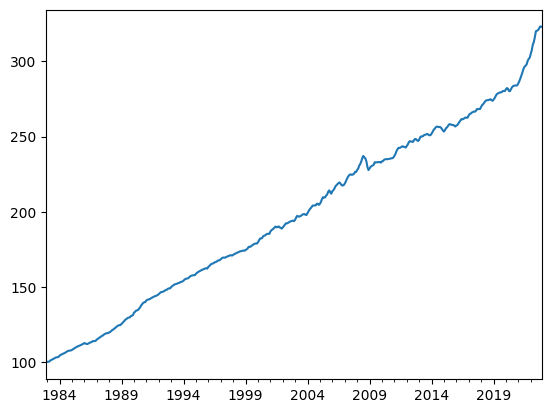

In [37]:
inf.plot();

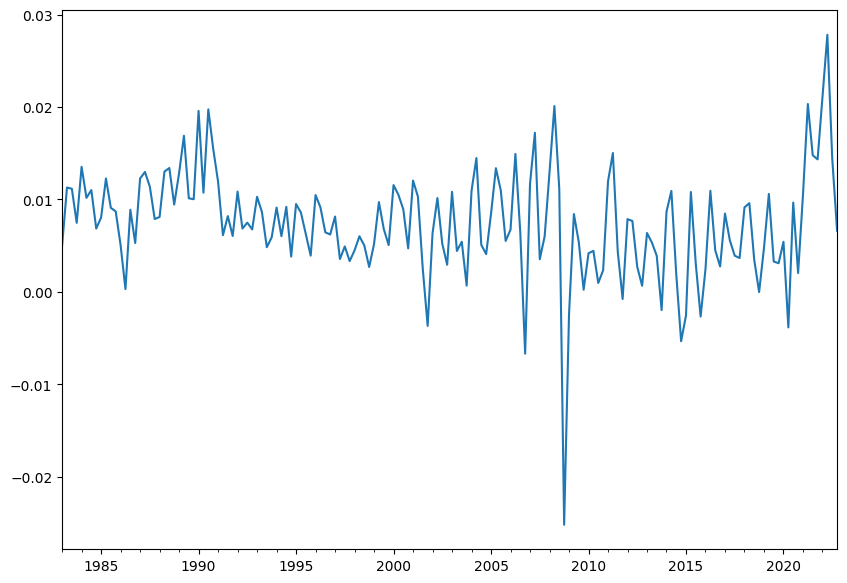

In [45]:
inf_quarterly=inf.resample("Q").mean()
inf_growth=inf_quarterly.pct_change().dropna()
inf_growth.plot(figsize=(10,7));

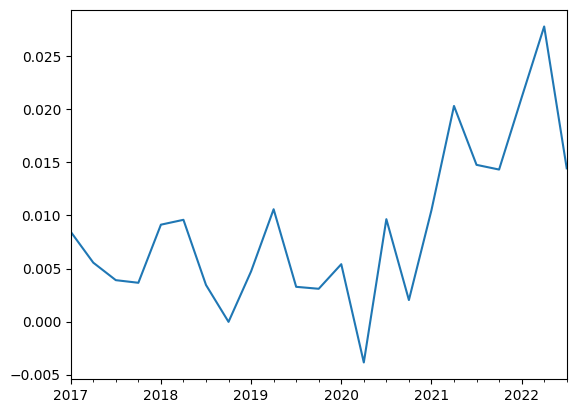

In [47]:
inf_growth.tail(24).iloc[:-1].plot();

# References
- https://technically.substack.com/p/whats-an-api
- https://technically.dev/posts/apis-for-the-rest-of-us
- https://aroussi.com/post/python-yahoo-finance
- https://github.com/ranaroussi/yfinance
- https://fred.stlouisfed.org